# Mechanical Properties Dataset

In [1]:
import requests
import pandas as pd

url = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/wfr5091_psu_edu/EYX7CVOMEdtKuGf-r6Eju70BkuoAMjSTqv0-ebh5WFVLQg?e=8Pu55u&download=1'
r = requests.get(url)

with open('data.csv', 'w') as fid:
    fid.write(r.text)

data = pd.read_csv('data.csv')
data

,Alloy code,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,V,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%)
0,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,27,342,490,30,71
1,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,100,338,454,27,72
2,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,200,337,465,23,69
3,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,300,346,495,21,70
4,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,400,316,489,26,79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,350,268,632,28,65
911,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,400,244,575,28,68
912,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,450,224,500,29,72
913,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,500,209,428,30,78


# Evaluate correlations

In [3]:
data.columns

Index(['Alloy code', ' C', ' Si', ' Mn', ' P', ' S', ' Ni', ' Cr', ' Mo',
       ' Cu', 'V', ' Al', ' N', 'Ceq', 'Nb + Ta', ' Temperature (°C)',
       ' 0.2% Proof Stress (MPa)', ' Tensile Strength (MPa)',
       ' Elongation (%)', ' Reduction in Area (%)'],
      dtype='object')

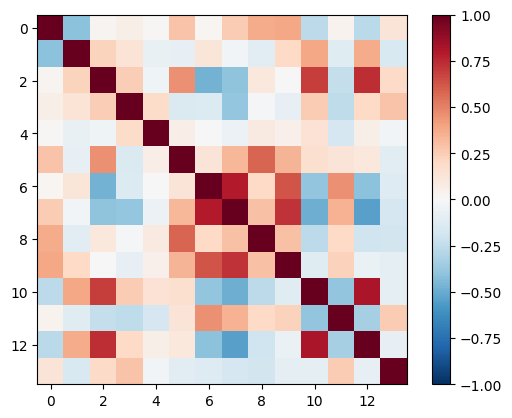

In [14]:
from matplotlib import pyplot as plt
im = plt.imshow(data.loc[:, ' C':'Nb + Ta'].corr(), cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im)

# Practical Example

In [2]:
import numpy as np

missing = data.copy(deep=True)

n_missing = 515
rng = np.random.default_rng(0)

miss_idx = []
for i, col in enumerate([' 0.2% Proof Stress (MPa)', ' Tensile Strength (MPa)',
                         ' Elongation (%)', ' Reduction in Area (%)']):
    rand_idx = rng.choice(np.arange(missing.shape[0]), n_missing, replace=False)
    missing.loc[rand_idx, col] = np.nan
    miss_idx.append(rand_idx)

missing

,Alloy code,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,V,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%)
0,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,27,342.0,490.0,NaN,71.0
1,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,100,NaN,NaN,NaN,72.0
2,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,200,NaN,NaN,NaN,NaN
3,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,300,NaN,NaN,NaN,NaN
4,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,400,NaN,NaN,26.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,350,268.0,NaN,NaN,NaN
911,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,400,244.0,NaN,NaN,NaN
912,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,450,NaN,NaN,29.0,NaN
913,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,500,209.0,428.0,30.0,NaN


# Soft Parameter Sharing

In [3]:
try:
    import pytorch_lightning as pl
except:
    !pip install pytorch_lightning
    import pytorch_lightning as pl

##  set up the datasets like so:

In [136]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from sklearn import preprocessing, model_selection

idx_train, idx_test_val = model_selection.train_test_split(np.arange(missing.shape[0]), random_state=0, test_size=0.40)
idx_test, idx_valid = model_selection.train_test_split(idx_test_val, random_state=0, test_size=0.50)

x_arr = missing.iloc[:, 1:-4].values.astype(float)  # 15 features (skip categorical codes)
y_arr = missing.iloc[:, -4:].values.astype(float)    # 4 labels (the mechanical properties)

x_scaler = preprocessing.StandardScaler().fit(x_arr[idx_train])
y_scaler = preprocessing.StandardScaler().fit(y_arr[idx_train])

x = torch.tensor(x_scaler.transform(x_arr)).float()
y = torch.tensor(y_scaler.transform(y_arr)).float()

ds_train = [(x[i], y[i]) for i in idx_train]
ds_valid = [(x[i], y[i]) for i in idx_valid]
ds_test = [(x[i], y[i]) for i in idx_test]

dl_train = DataLoader(ds_train, batch_size=64, shuffle=True)
dl_valid = DataLoader(ds_valid, batch_size=256, shuffle=False)
dl_test = DataLoader(ds_test, batch_size=256, shuffle=False)

## model architecture

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

# Shared MLP (shared across tasks)
class SharedMLP(nn.Module):
    def __init__(self, input_size, hidden_size, n_tasks, n_outputs, beta= 0.1):
        super().__init__()
        assert 0 <= beta <= 101
        self.input_size = input_size

        # Hidden layers
        h_sizes = [self.input_size] + [hidden_size for _ in range(n_tasks)] + [n_outputs]
        self.hidden = nn.ModuleList()

        # Create linear layers
        for k in range(len(h_sizes) - 1):
            self.hidden.append(nn.Linear(h_sizes[k], h_sizes[k + 1]))

        self.relu = nn.ReLU()

    def forward(self, x):
        for layer in self.hidden[:-1]:
            x = layer(x)  # Linear transformation
            x = self.relu(x)  # ReLU activation function
        return self.hidden[-1](x)

# Task-specific MLP for each task
class TaskSpecificMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, n_tasks):
        super(TaskSpecificMLP, self).__init__()
        self.task_nets = nn.ModuleList()  # List to hold task-specific networks

        for _ in range(n_tasks):
            layers = []
            sizes = [input_size] + list(hidden_sizes)
            for i in range(len(sizes) - 1):
                layers.append(nn.Linear(sizes[i], sizes[i + 1]))
                layers.append(nn.ReLU())
            self.task_nets.append(nn.Sequential(*layers))

        # Separate task heads
        self.task_heads = nn.ModuleList([nn.Linear(hidden_sizes[-1], 1) for _ in range(n_tasks)])

        # Apply consistent weight initialization
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.manual_seed(0)  # Set seed for reproducibility
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Shared outputs for each task-specific network
        shared_outputs = [net(x) for net in self.task_nets]
        return torch.cat([head(out) for head, out in zip(self.task_heads, shared_outputs)], dim=1)

In [6]:
# Soft parameter sharing MLP
class SoftSharingMLP(pl.LightningModule):
    def __init__(self, input_size, hidden_size, n_tasks, enable_sharing=True):
        super().__init__()
        self.model = TaskSpecificMLP(input_size, hidden_size, n_tasks)
        self.enable_sharing = enable_sharing
        self.n_tasks = n_tasks

    def get_param_groups(self):
        param_groups = []
        # Collect weights of each task for soft-sharing regularization
        for out in zip(*[n.named_parameters() for n in self.model.task_nets]):
            if 'weight' in out[0][0]:
                param_groups.append([out[i][1] for i in range(len(out))])
        return param_groups

    def soft_loss(self):
        if not self.enable_sharing:
            return torch.tensor(0.0)
        param_groups = self.get_param_groups()
        soft_sharing_loss = torch.tensor(0.0)
        for params in param_groups:
            soft_sharing_loss += torch.norm(params[0] - params[1], p='fro')
        return soft_sharing_loss  # Regularization loss between task-specific layers

    def forward(self, x):
        return self.model(x)

# Multi-task MSE Loss
class MultiTaskMSELoss(nn.Module):
    def __init__(self, reduction='mean'):
        super().__init__()
        if reduction not in ['mean', 'sum', 'none']:
            raise ValueError('Invalid reduction method')
        self.reduction = reduction

    def forward(self, input, target):
        # Mask out NaN values in the targets
        mask = ~torch.isnan(target)

        # Compute MSE, ignoring NaN values
        mse = F.mse_loss(input[mask], target[mask], reduction=self.reduction)

        return mse

## trainging loop

In [95]:
# Initialize model, loss function, optimizer
input_size = 15  # Number of features
hidden_size = (32, 16, 8, )  # Hidden layers
n_tasks = 4  # Number of tasks (mechanical properties)
model = SoftSharingMLP(input_size, hidden_size, n_tasks, enable_sharing=True)

criterion = MultiTaskMSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-2)

# Training loop
beta = 1e0  # Soft-sharing regularization parameter
max_epochs = int(1e5)
patience_interval = 2000
last_best = (0, np.inf)
model.train()

for epoch in range(max_epochs):
    optimizer.zero_grad()  # Zero the gradients from the previous step
    outputs = model(x[idx_train])  # Forward pass on the training data
    loss = criterion(outputs, y[idx_train])  # Task-specific loss
    sharing_loss = model.soft_loss()  # Soft sharing loss
    total_loss = loss + beta * sharing_loss  # Total loss
    total_loss.backward()  # Backpropagation
    optimizer.step()  # Update weights

    # Check for best performance
    if loss.item() < last_best[1]:
        last_best = (epoch, loss.item())

    # Validation step
    if (epoch + 1) % 100 == 0:
        with torch.no_grad():
            outputs = model(x[idx_valid])
            valid_loss = criterion(outputs, y[idx_valid])
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, Sharing Loss: {sharing_loss.item():.4f}, Val MSE: {valid_loss.item():.4f}')

    # Early stopping based on patience
    if epoch - last_best[0] > patience_interval:
        print('Patience expired...')
        break

Epoch 100, MSE: 0.0464, Sharing Loss: 0.1943, Val MSE: 0.1850
Epoch 200, MSE: 0.0303, Sharing Loss: 0.1890, Val MSE: 0.1945
Epoch 300, MSE: 0.0213, Sharing Loss: 0.1963, Val MSE: 0.2034
Epoch 400, MSE: 0.0197, Sharing Loss: 0.2074, Val MSE: 0.1982
Epoch 500, MSE: 0.0142, Sharing Loss: 0.1826, Val MSE: 0.2037
Epoch 600, MSE: 0.0160, Sharing Loss: 0.1966, Val MSE: 0.2043
Epoch 700, MSE: 0.0143, Sharing Loss: 0.2158, Val MSE: 0.2033
Epoch 800, MSE: 0.0114, Sharing Loss: 0.1964, Val MSE: 0.1987
Epoch 900, MSE: 0.0175, Sharing Loss: 0.1816, Val MSE: 0.1998
Epoch 1000, MSE: 0.0118, Sharing Loss: 0.2123, Val MSE: 0.1975
Epoch 1100, MSE: 0.0403, Sharing Loss: 0.1675, Val MSE: 0.2214
Epoch 1200, MSE: 0.0077, Sharing Loss: 0.2006, Val MSE: 0.2113
Epoch 1300, MSE: 0.0123, Sharing Loss: 0.2019, Val MSE: 0.2457
Epoch 1400, MSE: 0.0081, Sharing Loss: 0.2006, Val MSE: 0.2659
Epoch 1500, MSE: 0.0082, Sharing Loss: 0.2063, Val MSE: 0.1914
Epoch 1600, MSE: 0.0072, Sharing Loss: 0.2120, Val MSE: 0.2172
E

[0.06002374157287982, 0.06115869036843354, 0.12695697631862918, 0.0470218890163801]
[0.22162661148105064, 0.2958253952873192, 0.5685097407007258, 0.5632924484853988]


(0.0, 0.6)

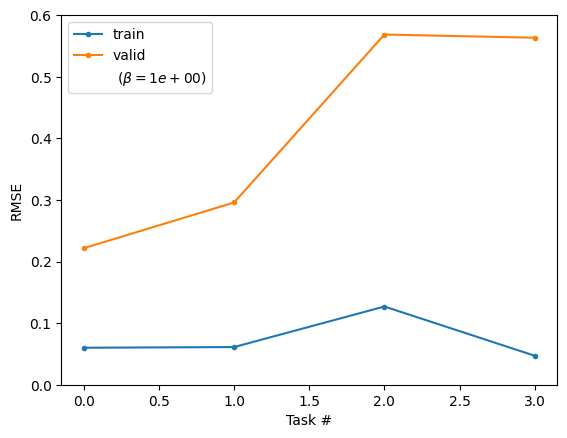

In [96]:
from matplotlib import pyplot as plt

for (l, xt, yt) in [('train', x[idx_train], y[idx_train]), ('valid', x[idx_test], y[idx_test])]:
    with torch.no_grad():
        out = model(xt)
    losses = np.zeros(model.n_tasks)
    for i in range(model.n_tasks):
        losses[i] = np.sqrt( criterion(out[:, i], yt[:, i]).mean().item() )

    plt.plot(losses, '.-', label=l)
    print(losses.tolist())
plt.plot(np.nan, np.nan, 'w.', label=f' $(\\beta = {beta:.0e}$)')
plt.legend(loc='upper left')
plt.xlabel('Task #')
plt.ylabel('RMSE')
plt.ylim(0, 0.60)

(0.0, 0.75)

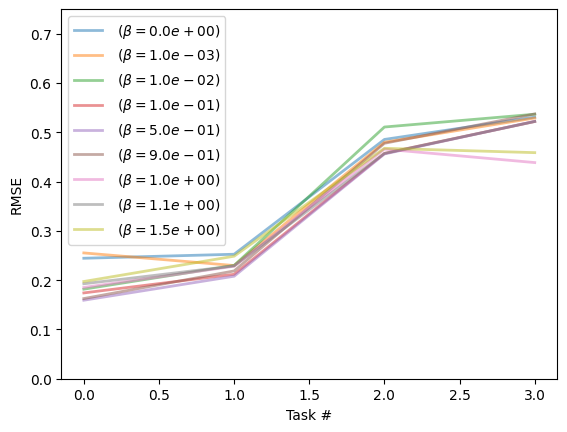

In [86]:
result = {
    0.0:  [0.2444592,  0.25259625, 0.48555828, 0.53086997],
    1e-3: [0.2552735559978371, 0.2296593970019432, 0.479789657152379, 0.5289889914677818],
    1e-2: [0.18173757652379757, 0.2298865642905865, 0.5107649730610645, 0.5367224114305634],    
    1e-1: [0.17413090471236412, 0.21189360805538562, 0.45725842885882767, 0.5219465914749714],
    0.5: [0.15931874619440134, 0.20798432302599706, 0.4560838808440571, 0.5223335182039087],
    0.9: [0.16266047206569603, 0.21871678066061986, 0.4777465868657796, 0.5373473039239448],
    1e0:  [0.18522039, 0.22823071, 0.46591577, 0.43860539],
    1.1: [0.1927017047532498, 0.22888111165249986, 0.45725842885882767, 0.5219465914749714],
    1.5: [0.19728613265297915, 0.24862750123397484, 0.46756266581921596, 0.45876727549795626],
    # 2e0: [0.18305145484251878, 0.24610978028903005, 0.6813561138138279, 0.4631778131969173],
    # 1e1:  [0.19647932, 0.25399237, 0.68467407, 0.46631912],
    # 1e2:  [0.28851638, 0.24649785, 0.690447,   0.47981051],
 }

for beta, values in result.items():
    plt.plot(np.arange(n_tasks), np.array(values), '-', lw=2, alpha=0.5, 
             label=f' $(\\beta = {beta:.1e}$)')
plt.legend(loc='upper left')
plt.xlabel('Task #')
plt.ylabel('RMSE')
plt.ylim(0, 0.75)

In [137]:
import sparsenn

# Initialize model, loss function, optimizer
input_size = 15  # Number of features
hidden_size = (64, 32, 16, )  # Hidden layers
n_tasks = 4  # Number of tasks (mechanical properties)
model = sparsenn.RegularizedMLPwithSkips(input_size, hidden_size, n_tasks)

criterion = MultiTaskMSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# Training loop
beta = 1e-6  # Soft-sharing regularization parameter
max_epochs = int(1e5)
patience_interval = 1000
last_best = (0, np.inf)
model.train()

for epoch in range(max_epochs):
    optimizer.zero_grad()  # Zero the gradients from the previous step
    outputs = model(x[idx_train])  # Forward pass on the training data
    loss = criterion(outputs, y[idx_train])  # Task-specific loss
    sharing_loss = model.regularization_loss()
    total_loss = loss + beta * sharing_loss  # Total loss
    total_loss.backward()  # Backpropagation
    optimizer.step()  # Update weights

    with torch.no_grad():
        outputs = model(x[idx_valid])
        valid_loss = criterion(outputs, y[idx_valid])

    # Check for best performance
    if valid_loss.item() < last_best[1]:
        last_best = (epoch, loss.item())

    # Validation step
    if (epoch + 1) % 100 == 0:
        with torch.no_grad():
            outputs = model(x[idx_valid])
            valid_loss = criterion(outputs, y[idx_valid])
            outputs = model(x[idx_test])
            test_loss = criterion(outputs, y[idx_test])
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, Sharing Loss: {sharing_loss.item():.4f}, Val MSE: {valid_loss.item():.4f}, Test MSE: {test_loss.item():.4f}')

    # Early stopping based on patience
    if epoch - last_best[0] > patience_interval:
        print('Patience expired...')
        break

Epoch 100, MSE: 0.4223, Sharing Loss: 3611.1355, Val MSE: 0.4090, Test MSE: 0.4285
Epoch 200, MSE: 0.1981, Sharing Loss: 3604.1436, Val MSE: 0.5983, Test MSE: 0.3004
Epoch 300, MSE: 0.1983, Sharing Loss: 3599.1282, Val MSE: 0.2191, Test MSE: 0.2161
Epoch 400, MSE: 0.2095, Sharing Loss: 3594.8945, Val MSE: 0.4470, Test MSE: 0.3289
Epoch 500, MSE: 0.1433, Sharing Loss: 3592.6147, Val MSE: 0.2060, Test MSE: 0.2785
Epoch 600, MSE: 0.1423, Sharing Loss: 3589.5962, Val MSE: 0.2009, Test MSE: 0.2325
Epoch 700, MSE: 0.1411, Sharing Loss: 3586.6345, Val MSE: 0.2010, Test MSE: 0.2088
Epoch 800, MSE: 0.1158, Sharing Loss: 3587.9495, Val MSE: 0.2494, Test MSE: 0.1831
Epoch 900, MSE: 0.1616, Sharing Loss: 3590.8542, Val MSE: 0.1645, Test MSE: 0.2091
Epoch 1000, MSE: 0.1147, Sharing Loss: 3593.7913, Val MSE: 0.1702, Test MSE: 0.1717
Epoch 1100, MSE: 0.1217, Sharing Loss: 3598.2339, Val MSE: 0.1686, Test MSE: 0.1549
Epoch 1200, MSE: 0.0999, Sharing Loss: 3599.3064, Val MSE: 0.1720, Test MSE: 0.2483
E

KeyboardInterrupt: 

In [133]:
model.eval()
gated_weights = [
    module.weight * torch.clamp(torch.sigmoid(module.log_alpha) * (module.zeta - module.gamma) + module.gamma, 0, 1)
    for module in model.layers if isinstance(module, sparsenn.L0Linear)
]
thresh = 1e-12
layer_weights = [(it > thresh).sum() for it in gated_weights]
print(layer_weights)
print(np.sum(layer_weights))

[tensor(127), tensor(291), tensor(186), tensor(40)]
644


[0.02658039228458437, 0.023779057916697793, 0.025377994843919453, 0.023117529987161906]
[0.23247545890855112, 0.2732044043877796, 0.47089521358720193, 0.4710553699250897]


(0.0, 0.6)

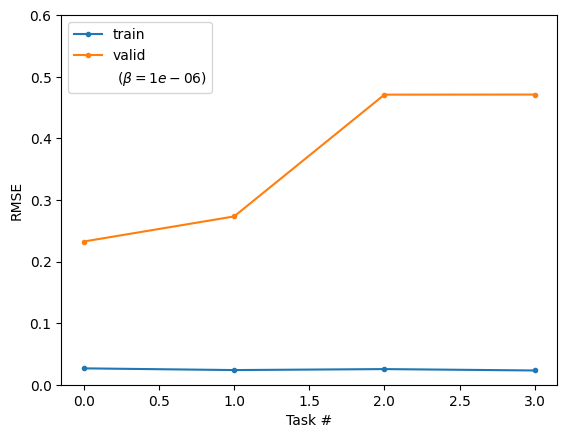

In [135]:
from matplotlib import pyplot as plt

model.eval()

for (l, xt, yt) in [('train', x[idx_train], y[idx_train]), ('valid', x[idx_test], y[idx_test])]:
    with torch.no_grad():
        out = model(xt)
    losses = np.zeros(n_tasks)
    for i in range(n_tasks):
        losses[i] = np.sqrt( criterion(out[:, i], yt[:, i]).mean().item() )

    plt.plot(losses, '.-', label=l)
    print(losses.tolist())
plt.plot(np.nan, np.nan, 'w.', label=f' $(\\beta = {beta:.0e}$)')
plt.legend(loc='upper left')
plt.xlabel('Task #')
plt.ylabel('RMSE')
plt.ylim(0, 0.60)